The point of this notebook is to demonstrate the idea of learning a loss landscape using a neural network and using gradient descent to optimize the input with respect to that cost function.

It shows a toy sample of learning the L2 loss landscape y = (x)^2 and optimizing for x using the gradient of the input with respect to the output. 

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import glob
import torch
import torch.nn as nn
import torch.nn.functional as F

import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleNN(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.activation = nn.ReLU()
        self.linear1 = nn.Linear(1,128)
        self.linear2 = nn.Linear(128,1)

    def forward(self, x):
        x = self.activation(self.linear1(x))
        x = self.linear2(x)
        return x

def train_model(model,X,Y,epochs=50):
    X = torch.tensor(X).float()
    Y = torch.tensor(Y).float()
    optimizer = torch.optim.Adagrad(model.parameters(), lr=1e-2)

    loss_record = []
    batch_size = 32
    criterion = torch.nn.MSELoss()
    for epoch in range(epochs):
        total_loss = 0
        for index in range(len(X)):
            # Grabs our sample from our training data 
            input_x = X[index].unsqueeze(0)
            input_y = Y[index].unsqueeze(0)
            # Runs our sample through our network
            output = model.forward(input_x)
            # Calculates the loss
            loss = criterion(output, input_y)
            # Resets the gradient of the optimizer
            optimizer.zero_grad()
            # Performs the backwards pass, finding dL/dW
            loss.backward()
            total_loss += loss.item()
            # Performs one optimizer step
            optimizer.step()
        total_loss/len(X)
        loss_record.append(total_loss)
    return model,loss_record

def model_pr_descent(x_init, model, iterations=100, lr=0.01):
    x_record = []
    cost_record = []
    grad_record = []
    input = torch.tensor(x_init).float().unsqueeze(0)
    input = torch.autograd.Variable(input, requires_grad=True)
    model.zero_grad()
    for iter in range(iterations):
        output = model(input)
        output.backward()
        grad = input.grad
        with torch.no_grad():
            input -= lr * grad # P Update
        # stores. why not 
        x_record.append(input[0].item())
        cost_record.append(output.item())
        grad_record.append(grad.item())
        grad.zero_()
    #return input[0].item(),input[1].item() # returns predicted P, R
    return x_record, cost_record,grad_record


In [18]:
toy_sim_model = SimpleNN()
a = 10
b = -10
X = (b - a) * np.random.random_sample(200,) + a
Y = (X-5) ** 2

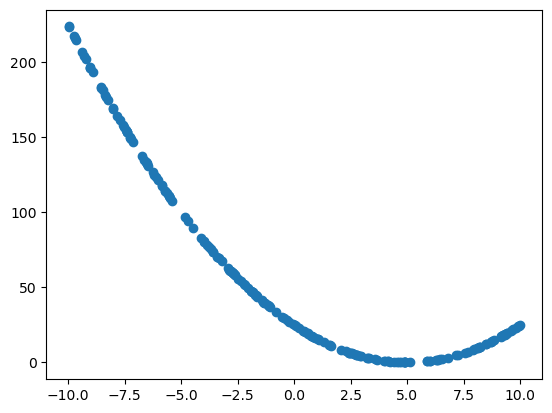

In [19]:
plt.scatter(X,Y)

In [24]:
toy_sim_model,loss_record = train_model(toy_sim_model,X,Y)


4991.252166722108


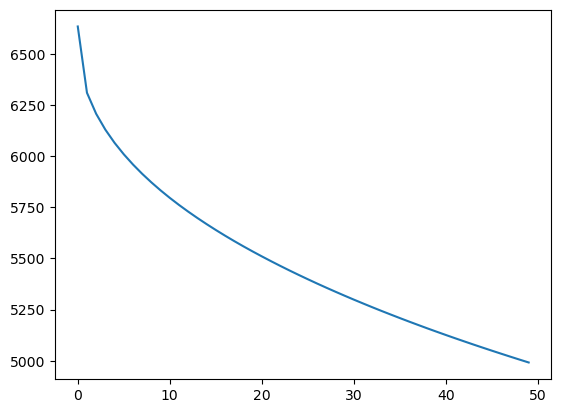

In [25]:
plt.plot(range(len(loss_record[0:])),loss_record[0:])
print(loss_record[-1])

In [30]:
x_steps,cost_thing,grad_record = model_pr_descent(1, model=toy_sim_model,iterations=1000,lr=.01)

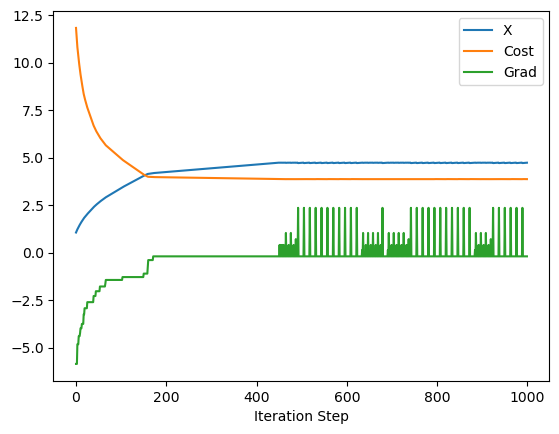

In [31]:
#plt.plot(range(len(input[:,0])),input[:,0],label='P')
plt.plot(range(len(x_steps)),x_steps,label='X')
plt.plot(range(len(cost_thing)),cost_thing,label='Cost')
plt.plot(range(len(grad_record)),np.array(grad_record),label='Grad')

plt.xlabel('Iteration Step')
plt.legend()